In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.spatial.distance import cdist
from scipy.sparse.csgraph import dijkstra
from scipy.spatial.transform import Rotation

#from isomap_master.isomap import make_adjacency, isomap, plot_graph
from sklearn.decomposition import PCA

from Utility import *
#from SampleMaker import make_sample_vectorized
#from DownSampler import load_and_downsample
#from SampleCombiner import combine_to_7d_tensor, combine_to_7d
#from WeatheringScore import compute_weather_score
import time
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [4]:

import numpy as np

def generate_curved_plane_grid_7d(
    grid_size=128,
    noise_std=0.02,
    random_state=42
):
    """
    7차원 공간 상의 구부러진 2D manifold grid 생성.

    반환:
        points : (grid_size * grid_size, 7)

    특징:
    - intrinsic dimension = 2
    - ambient dimension = 7
    - grid topology 유지
    - 비선형 곡면 구조
    """

    rng = np.random.default_rng(random_state)

    # -----------------------------
    # 2D parameter grid
    # -----------------------------
    u = np.linspace(-2.0, 2.0, grid_size)
    v = np.linspace(-2.0, 2.0, grid_size)

    U, V = np.meshgrid(u, v)

    u = U.reshape(-1)
    v = V.reshape(-1)

    # -----------------------------
    # Nonlinear embedding into R^7
    # -----------------------------
    x1 = u
    x2 = v

    x3 = 0.7 * np.sin(u)
    x4 = 0.7 * np.cos(v)

    x5 = 0.5 * np.sin(u * v)

    x6 = 0.3 * (u**2 - v**2)

    x7 = 0.4 * np.sin(
        2.0 * np.sqrt(u**2 + v**2)
    )

    points = np.stack(
        [x1, x2, x3, x4, x5, x6, x7],
        axis=1
    )

    # -----------------------------
    # Noise
    # -----------------------------
    points += rng.normal(0.0, noise_std, size=points.shape)

    return points

In [5]:
m = generate_curved_plane_grid_7d()

print(m.shape)
# (400, 7)

#m = m.reshape(20, 20, 7)
print(m)

(16384, 7)
[[-1.99390566 -2.02079968 -0.62149917 ... -0.41742195 -0.02604359
  -0.23191367]
 [-1.97482879 -2.00033602 -0.66242677 ... -0.34152132 -0.03617706
  -0.22606787]
 [-1.92765769 -2.01718585 -0.64620841 ... -0.31676765 -0.07539867
  -0.26585442]
 ...
 [ 1.94238834  1.96852813  0.68106173 ... -0.34364987 -0.09655427
  -0.26488431]
 [ 1.93716871  2.00196931  0.61004335 ... -0.36456885 -0.05286342
  -0.26051476]
 [ 1.98823216  1.99992747  0.65651201 ... -0.35838675  0.02766252
  -0.21294699]]


In [6]:
from KNN import Get_KNN_graph, Get_KNN_Graph_Adaptive, Get_KNN_Graph_Adaptive_Streaming
from Geodesic import Get_Geodesic_Distance_Matrix, Get_Geodesic_Distance_Matrix_GPU
from MDS import Get_MDS_graph, Get_MDS_graph_GPU, visualize_MDS_Graph, visualize_MDS_Graph_Edges, visualize_MDS_Graph_Edges_2D

In [7]:
Z = normalize_features(m)
print(Z.shape[0])
print(Z)

16384
[[0.01347186 0.00604596 0.09585892 ... 0.13432486 0.48630515 0.24426588]
 [0.01812598 0.01103175 0.06901871 ... 0.20150597 0.4822379  0.25065222]
 [0.02963417 0.00692641 0.07965467 ... 0.22341594 0.46649566 0.20718665]
 ...
 [0.9737977  0.9780083  0.9500752  ... 0.19962196 0.45800453 0.20824644]
 [0.9725242  0.98615587 0.9035016  ... 0.18110615 0.47554052 0.21302006]
 [0.9849821  0.9856584  0.9339756  ... 0.18657805 0.5078609  0.2649864 ]]


In [8]:
src, dst, wei, wea = Get_KNN_Graph_Adaptive(Z, K=8)
#src, dst, wei, wea = Get_KNN_Graph_Adaptive_Streaming(Z, K=4)
print(src, src.shape)
print(dst, dst.shape)
print(wei, wei.shape)
print(wea)

[    0     0     0 ... 16383 16383 16383] (131050,)
[    1   128   129 ... 16381 16254 15999] (131050,)
[0.07223766 0.07681387 0.08309484 ... 0.08652037 0.0950454  0.10231406] (131050,)
[0.6101501  0.6425763  0.58157265 ... 0.7527339  0.7396847  0.7771701 ]


In [9]:
N = Z.shape[0]
#N = wei.shape[0]
D = Get_Geodesic_Distance_Matrix(src, dst, wei, N)

print(D.shape)
print(D)



(16384, 16384)
[[0.         0.14885849 0.11141164 ... 7.24723992 7.25669721 7.20471203]
 [0.14885849 0.         0.13074027 ... 7.21507119 7.22452847 7.17254329]
 [0.11141164 0.13074027 0.         ... 7.21486275 7.22432003 7.17233485]
 ...
 [7.24723992 7.21507119 7.21486275 ... 0.         0.11052497 0.08652037]
 [7.25669721 7.22452847 7.22432003 ... 0.11052497 0.         0.15970446]
 [7.20471203 7.17254329 7.17233485 ... 0.08652037 0.15970446 0.        ]]


In [10]:
#D2 = Get_Geodesic_Distance_Matrix_GPU(src, dst, wei, wea.shape[0])
#print(D2.shape)
#print(D2)

In [ ]:
M = Get_MDS_graph(D, 3)
#M = Get_MDS_graph_GPU(D, 3)
print(M.shape)
print(M)

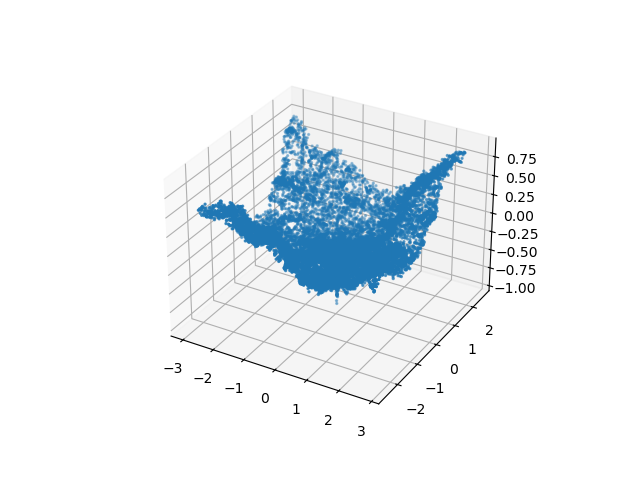

In [ ]:
visualize_MDS_Graph(M,Z)

In [ ]:
visualize_MDS_Graph_Edges(M, src, dst, Z)

KeyboardInterrupt: 

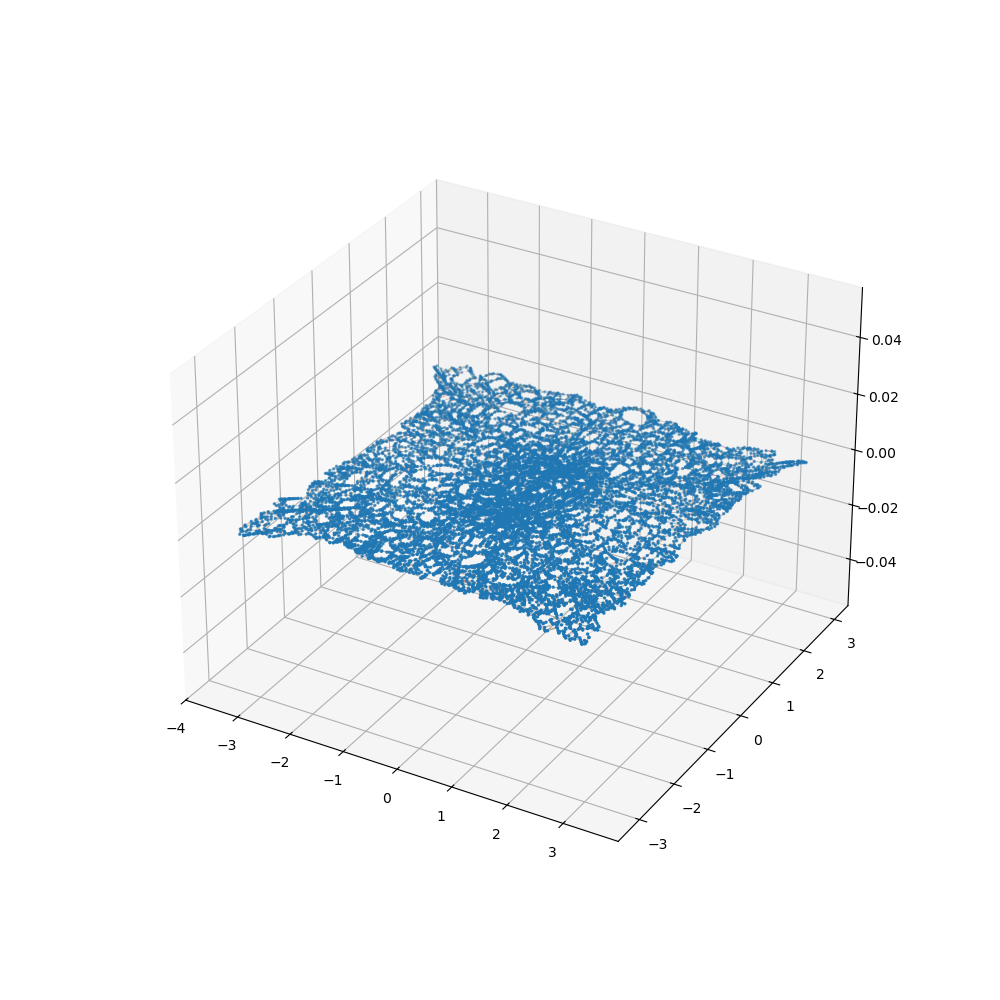

In [ ]:
visualize_MDS_Graph_Edges_2D(M, src, dst, Z)

In [ ]:
from Trajectory import * 

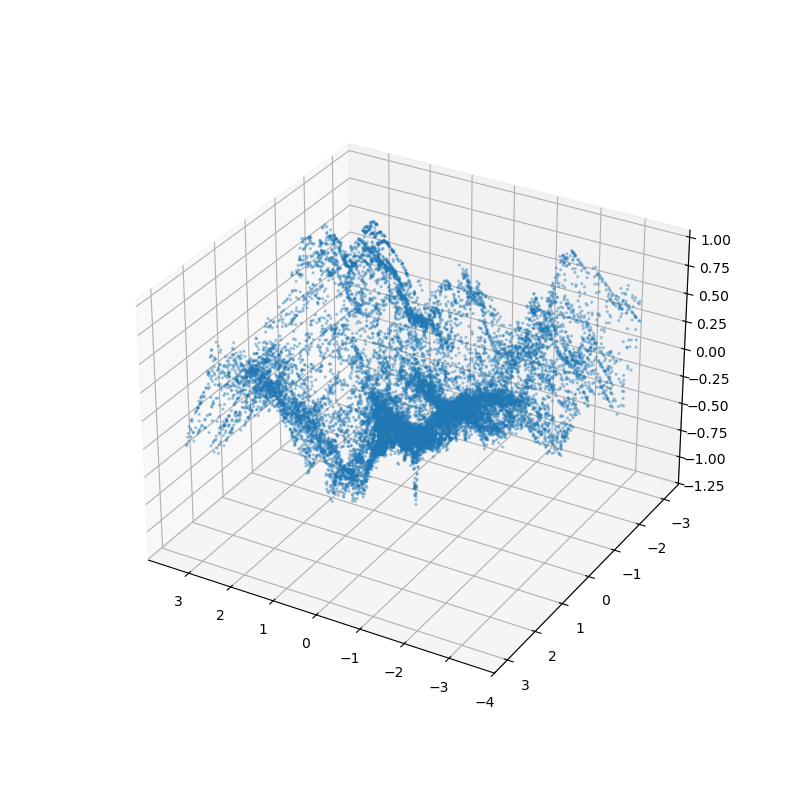

In [ ]:
start_idx = np.argmin(wea)
end_idx = np.argmax(wea)

trajectory_points, trajectory_nodes = (
    build_weathering_trajectory(
        embedded=M,
        edge_src=src,
        edge_dst=dst,
        edge_weight=wei,
        start_idx=start_idx,
        end_idx=end_idx
    )
)

trajectory = resample_trajectory(
    trajectory_points,
    num_points=256
)

visualize_trajectory(M, trajectory)



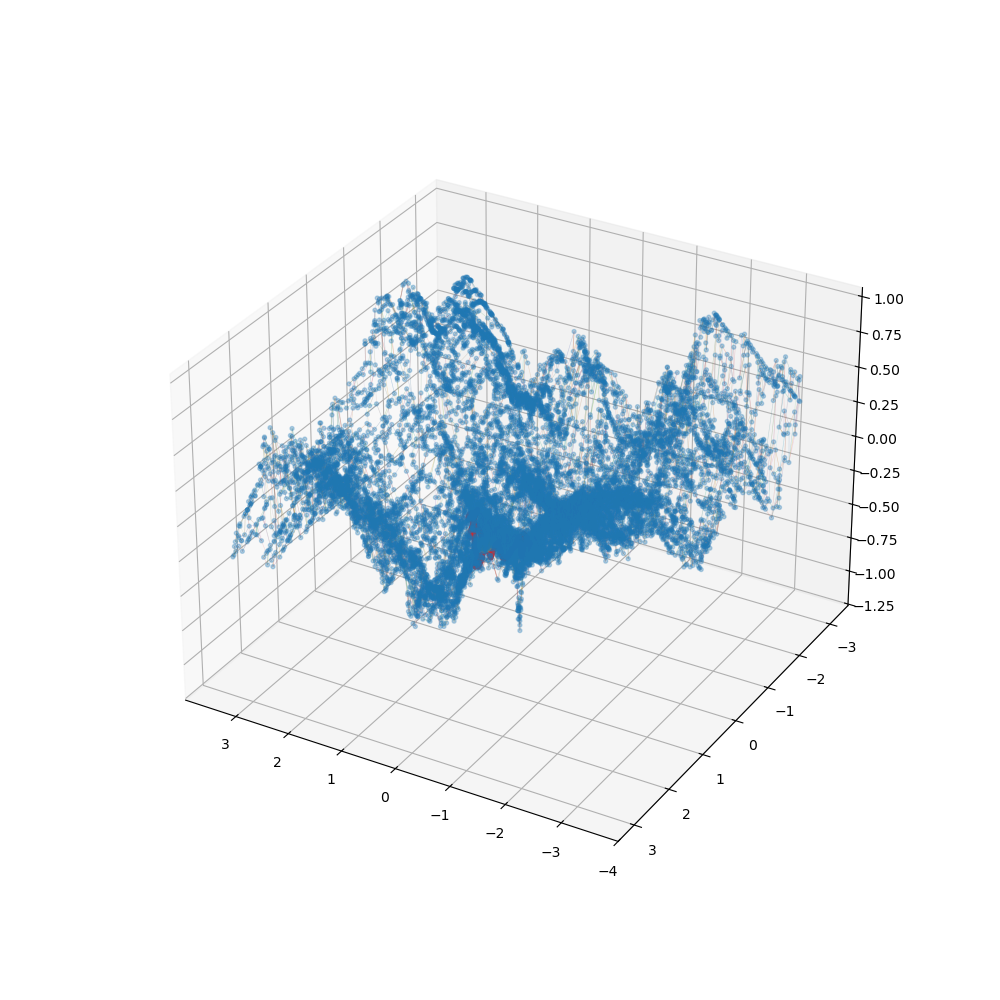

In [ ]:
from Utility import visualize_MDS_Graph_With_Trajectory

visualize_MDS_Graph_With_Trajectory(
    Z=M,
    edge_src=src,
    edge_dst=dst,
    trajectory=trajectory
)